In [1]:
import pandas as pd

# Step 1: Load the raw dataset from Food.com (Kaggle)
# Note: Ensure 'RAW_recipes.csv' is placed in the correct directory
raw_df = pd.read_csv('../RAW_recipes.csv')

# Step 2: Define comprehensive keywords for baking, bread, and desserts
# This broadens our search beyond just cakes and cookies to include all baking items
baking_keywords = 'cake|cookie|bread|tart|pie|muffin|pastry|brownie|pancake|waffle|doughnut|dessert|pudding|cupcake'

# Step 3: Filter the dataset using the specified keywords
# 'case=False' makes the search case-insensitive, and 'na=False' handles empty rows safely
baking_df =baking_df = raw_df[raw_df['name'].str.contains(baking_keywords, case=False, na=False)].copy()

# Step 4: Calculate and display statistics for data exploration
total_recipes = len(raw_df)
total_baking_recipes = len(baking_df)
baking_percentage = (total_baking_recipes / total_recipes) * 100

print("--- Dataset Summary Statistics ---")
print(f"Total recipes in raw dataset: {total_recipes:,}")
print(f"Total baking & dessert recipes filtered: {total_baking_recipes:,}")
print(f"Baking domain percentage: {baking_percentage:.2f}%")

# Step 5: Preview the first 5 rows of the filtered dataset
print("\n--- Filtered Dataset Preview ---")
print(baking_df[['name', 'ingredients', 'minutes']].head())

--- Dataset Summary Statistics ---
Total recipes in raw dataset: 231,637
Total baking & dessert recipes filtered: 44,007
Baking domain percentage: 19.00%

--- Filtered Dataset Preview ---
                           name  \
8      bananas 4 ice cream  pie   
9       beat this  banana bread   
23   deep fried dessert thingys   
30  get the sensation  brownies   
32         grilled  ranch bread   

                                          ingredients  minutes  
8   ['chocolate sandwich style cookies', 'chocolat...      180  
9   ['sugar', 'unsalted butter', 'bananas', 'eggs'...       70  
23  ['all-purpose flour', 'granulated sugar', 'bak...       20  
30  ['butter', 'sugar', 'vanilla', 'eggs', 'all-pu...       70  
32  ['butter', 'dry ranch dressing mix', 'french b...       13  


In [2]:
import ast

# Step 1: Convert the string representation of lists into actual Python lists
# We use ast.literal_eval for safe evaluation of the string data
baking_df['clean_ingredients'] = baking_df['ingredients'].apply(ast.literal_eval)

# Step 2: Verify the transformation by checking the data type of the first row
# The output should confirm it is now a <class 'list'>
print (type(baking_df['clean_ingredients'].iloc[0]))

<class 'list'>


In [3]:
from collections import Counter

# Step 1: Flatten the list of lists into a single continuous list of ingredients
all_ingredients = []
for row in baking_df['clean_ingredients']:
    all_ingredients.extend(row)

# Step 2: Count the frequency of each ingredient across the dataset
count = Counter(all_ingredients)

# Step 3: Extract and display the top 10 most frequent ingredients
top_10_ingredients = count.most_common(10)
print(top_10_ingredients)

[('salt', 22749), ('sugar', 18991), ('eggs', 18654), ('butter', 17969), ('baking powder', 12885), ('flour', 11957), ('baking soda', 11486), ('milk', 9579), ('all-purpose flour', 9486), ('vanilla', 8954)]


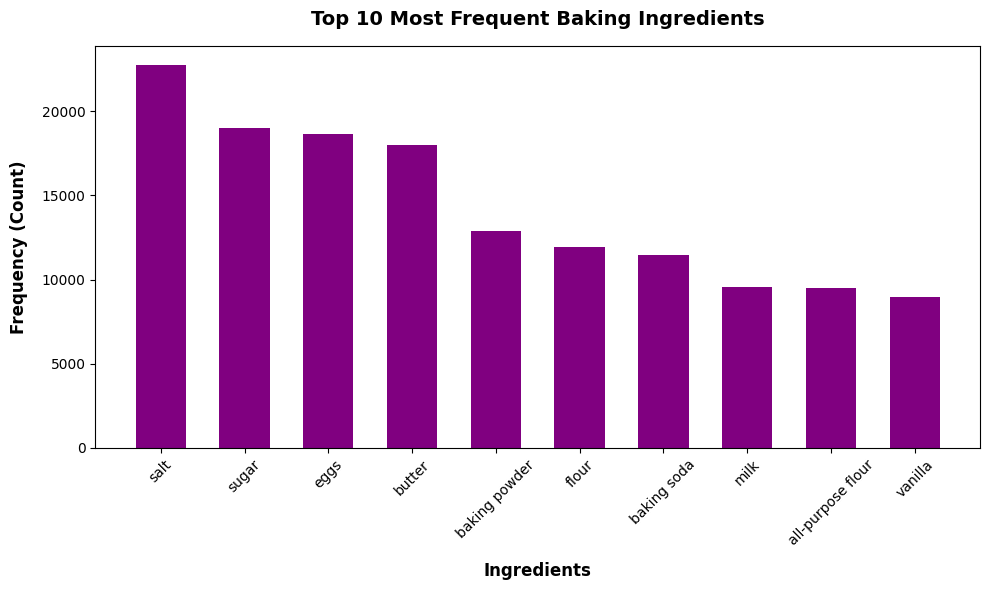

In [4]:
import matplotlib.pyplot as plt

# Step 1: Get the top 10 most common ingredients
top_10_ingredients = count.most_common(10)

# Step 2: Separate ingredient names and their frequencies into two distinct lists
ingredients = []
counts = []

for item in top_10_ingredients:
    ingredients.append(item[0])  # Extract ingredient name
    counts.append(item[1])       # Extract ingredient count

# Step 3: Initialize the plot with a professional figure size
plt.figure(figsize=(10, 6))

# Step 4: Create the bar chart with your chosen purple color
plt.bar(ingredients, counts, color="purple", width=0.6)

# Step 5: Customize fonts, titles, and labels for better readability
plt.title("Top 10 Most Frequent Baking Ingredients", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ingredients", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Frequency (Count)", fontsize=12, fontweight='bold', labelpad=10)

# Step 6: Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Step 7: Clean up the layout and display the final chart
plt.tight_layout()
plt.show()

In [5]:
# A list of words that need to be removed so the computer can find the core ingredient
baking_stop_words = [
    'cup', 'cups', 'gram', 'grams', 'g', 'oz', 'ounce', 'ounces', 'lb', 'pound',
    'tbsp', 'tablespoon', 'tablespoons', 'tsp', 'teaspoon', 'teaspoons',
    'melted', 'fresh', 'warm', 'cold', 'chopped', 'softened', 'ground', 
    'powdered', 'packed', 'sifted', 'divided', 'plus', 'optional', 'of'
]

In [6]:
import re

def clean_recipe_ingredients(ingredient_list):
    cleaned_list = []
    
    for text in ingredient_list:
        # Convert text to lowercase for consistency
        text = text.lower()
        
        # Remove numbers and special characters (like 1/2, 1, 2)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Split the text into individual words
        words = text.split()
        
        # Filter out the baking stop words
        valid_words = []
        for word in words:
            if word not in baking_stop_words:
                valid_words.append(word)
        
        # Join the safe words back into a single string
        cleaned_ingredient = " ".join(valid_words)
        
        # Append to the final list if the string is not empty
        if cleaned_ingredient:
            cleaned_list.append(cleaned_ingredient)
        
    return cleaned_list

In [7]:
# Apply the cleaning function to the dataset and create a new column
baking_df['standard_ingredients'] = baking_df['clean_ingredients'].apply(clean_recipe_ingredients)

# Preview the first few rows to see the magic!
print(baking_df[['clean_ingredients', 'standard_ingredients']].head())

                                    clean_ingredients  \
8   [chocolate sandwich style cookies, chocolate s...   
9   [sugar, unsalted butter, bananas, eggs, fresh ...   
23  [all-purpose flour, granulated sugar, baking p...   
30  [butter, sugar, vanilla, eggs, all-purpose flo...   
32     [butter, dry ranch dressing mix, french bread]   

                                 standard_ingredients  
8   [chocolate sandwich style cookies, chocolate s...  
9   [sugar, unsalted butter, bananas, eggs, lemon ...  
23  [allpurpose flour, granulated sugar, baking po...  
30  [butter, sugar, vanilla, eggs, allpurpose flou...  
32     [butter, dry ranch dressing mix, french bread]  


In [8]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# 1. Initialize the binarizer
mlb = MultiLabelBinarizer()

# 2. Transform the 'standard_ingredients' column into a matrix of 0s and 1s
ingredient_matrix = mlb.fit_transform(baking_df['standard_ingredients'])

# 3. Convert the numpy matrix into a clean DataFrame so we can see it
# The columns will be the actual distinct ingredient names!
matrix_df = pd.DataFrame(ingredient_matrix, columns=mlb.classes_, index=baking_df.index)

# 4. Preview the first few rows and columns of our new matrix
print("Matrix Shape:", matrix_df.shape)
print(matrix_df.iloc[:5, :10]) # Shows first 5 recipes and first 10 ingredients

Matrix Shape: (44007, 7016)
    a original sauce  a steak sauce  abalone steak  absolut citron vodka  \
8                  0              0              0                     0   
9                  0              0              0                     0   
23                 0              0              0                     0   
30                 0              0              0                     0   
32                 0              0              0                     0   

    absolut vodka  accent seasoning  acorn meal  acorn squash  \
8               0                 0           0             0   
9               0                 0           0             0   
23              0                 0           0             0   
30              0                 0           0             0   
32              0                 0           0             0   

    active dry yeast  active starter  
8                  0               0  
9                  0               0  
23     

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Let's calculate the similarity matrix for our recipes
# To prevent memory issues with 44k recipes, we can test it on the first 1000 recipes first
similarity_matrix = cosine_similarity(ingredient_matrix[:1000])

# 2. Print the shape of our new similarity matrix
print("Similarity Matrix Shape:", similarity_matrix.shape)

# 3. Let's see how similar Recipe 0 is to Recipe 1
print("Similarity between Recipe 0 and Recipe 1:", similarity_matrix[0][1])

Similarity Matrix Shape: (1000, 1000)
Similarity between Recipe 0 and Recipe 1: 0.13608276348795434


In [10]:
import numpy as np

# Let's find the top 5 most similar recipes to Recipe #8 (the chocolate cookies one!)
recipe_id = 8
similarity_scores = similarity_matrix[recipe_id]

# Sort the scores and get the indexes of top 5 highest similarities (excluding itself)
similar_indices = np.argsort(similarity_scores)[::-1][1:6]

print(f"--- Top 5 Recipes Similar to Recipe {recipe_id} ---")
for idx in similar_indices:
    print(f"Recipe Index: {idx} | Similarity Score: {similarity_scores[idx]:.4f}")
    print(f"Ingredients: {baking_df['clean_ingredients'].iloc[idx]}\n")

--- Top 5 Recipes Similar to Recipe 8 ---
Recipe Index: 48 | Similarity Score: 0.4835
Ingredients: ['all-purpose flour', 'baking soda', 'salt', 'baking powder', 'cinnamon', 'nutmeg', 'allspice', 'ground cloves', 'sugar', 'water', 'oil', 'eggs', 'pumpkin', 'pecans']

Recipe Index: 506 | Similarity Score: 0.4264
Ingredients: ['yellow cake mix', 'apple pie filling', 'eggs', 'cinnamon', 'cardamom', 'nutmeg', 'ground cloves', 'nuts']

Recipe Index: 407 | Similarity Score: 0.4264
Ingredients: ['lemon cake mix', 'instant pineapple pudding', 'eggs', 'oil', '7-up soda', 'crushed pineapple', 'butter', 'coconut']

Recipe Index: 357 | Similarity Score: 0.4045
Ingredients: ['crushed pineapple', 'cherry pie filling', 'yellow cake mix', 'butter', 'pecans']

Recipe Index: 828 | Similarity Score: 0.3892
Ingredients: ['yellow cake mix', 'eggs', 'cream sherry', 'vegetable oil', 'vanilla instant pudding mix', 'nutmeg', 'brown sugar', 'flour', 'cinnamon', 'firm butter', 'almonds', 'powdered sugar', 'butter

In [11]:
# 1. Define the ingredients available to the user in a 2D list (list of lists)
user_ingredients = [['flour', 'cocoa', 'vanilla']]

# 2. Transform the user input into a binary vector of shape (1, 7016)
# We use 'transform' (NOT 'fit_transform') to align it with the existing vocabulary
user_vector = mlb.transform(user_ingredients)

# 3. Verify the vector shape to ensure it matches the database columns
print(user_vector.shape)

(1, 7016)


In [12]:
# 1. Define the ingredients available in the user's kitchen
user_ingredients = [['butter', 'almonds', 'chocolate']]

# 2. Convert user ingredients into a binary vector matching the 7016 features
user_vector = mlb.transform(user_ingredients)

# 3. Calculate cosine similarity between user vector and all 44,000+ recipes
user_scores = cosine_similarity(user_vector, ingredient_matrix)[0]

# 4. Extract the indices of the top 5 most similar recipes
top_indices = np.argsort(user_scores)[::-1][:5]

# Convert user ingredients list to a set for fast comparison
user_set = set(user_ingredients[0])

print("--- Recommendations with Missing Ingredients Analysis ---")
for idx in top_indices:
    recipe_name = baking_df['name'].iloc[idx]
    recipe_ingredients = baking_df['clean_ingredients'].iloc[idx] # This is already a list
    score = user_scores[idx]
    
    # Calculate missing ingredients using set subtraction
    missing_ingredients = list(set(recipe_ingredients) - user_set)
    missing_count = len(missing_ingredients)
    
    print(f"Recipe: {recipe_name.title()} (Index: {idx})")
    print(f"Similarity Score: {score:.4f}")
    print(f"Ingredients Needed: {recipe_ingredients}")
    print(f"🚨 Missing Ingredients ({missing_count}): {missing_ingredients}")
    print("-" * 50 + "\n")

--- Recommendations with Missing Ingredients Analysis ---
Recipe: Shortbread Almond Cookie Crust (Index: 36314)
Similarity Score: 0.6667
Ingredients Needed: ['shortbread cookies', 'ground almonds', 'butter']
🚨 Missing Ingredients (2): ['shortbread cookies', 'ground almonds']
--------------------------------------------------

Recipe: Chocolate Dessert Cake (Index: 9838)
Similarity Score: 0.6124
Ingredients Needed: ['chocolate', 'butter', 'caster sugar', 'ground almonds', 'instant coffee', 'hot water', 'eggs', 'cocoa powder']
🚨 Missing Ingredients (6): ['ground almonds', 'caster sugar', 'eggs', 'cocoa powder', 'instant coffee', 'hot water']
--------------------------------------------------

Recipe: Low Carb Cheesecake Nut Crust (Index: 24689)
Similarity Score: 0.5774
Ingredients Needed: ['ground almonds', 'splenda sugar substitute', 'butter', 'unsweetened cocoa powder']
🚨 Missing Ingredients (3): ['unsweetened cocoa powder', 'ground almonds', 'splenda sugar substitute']
---------------

In [13]:
# 1. Define the penalty weight for each missing ingredient
penalty_weight = 0.05

# 2. Extract recipe ingredient lists from the dataframe
recipe_ingredients_list = baking_df['clean_ingredients'].tolist()

# 3. Calculate the number of missing ingredients for ALL recipes in the database
# We compare each recipe's ingredients against the user's ingredients set
user_set = set(user_ingredients[0])
missing_counts = np.array([len(set(rec) - user_set) for rec in recipe_ingredients_list])

# 4. Calculate the finalized score by applying the penalty to the cosine similarity scores
final_scores = user_scores - (missing_counts * penalty_weight)

# 5. Get the top 5 indices based on the new finalized scores
top_indices_penalized = np.argsort(final_scores)[::-1][:5]

# 6. Display the new smart recommendations
print("--- Smart Recommendations (Optimized with Missing Ingredients Penalty) ---")
for idx in top_indices_penalized:
    recipe_name = baking_df['name'].iloc[idx]
    recipe_ingredients = baking_df['clean_ingredients'].iloc[idx]
    original_similarity = user_scores[idx]
    final_score = final_scores[idx]
    missing_ingredients = list(set(recipe_ingredients) - user_set)
    
    print(f"Recipe: {recipe_name.title()} (Index: {idx})")
    print(f"Original Similarity: {original_similarity:.4f} | Penalized Score: {final_score:.4f}")
    print(f"Ingredients Needed: {recipe_ingredients}")
    print(f"🚨 Missing Ingredients ({len(missing_ingredients)}): {missing_ingredients}")
    print("-" * 50 + "\n")

--- Smart Recommendations (Optimized with Missing Ingredients Penalty) ---
Recipe: Shortbread Almond Cookie Crust (Index: 36314)
Original Similarity: 0.6667 | Penalized Score: 0.5667
Ingredients Needed: ['shortbread cookies', 'ground almonds', 'butter']
🚨 Missing Ingredients (2): ['shortbread cookies', 'ground almonds']
--------------------------------------------------

Recipe: Quick Choc Mousse Filling For Cakes Or Swiss Roll (Index: 33848)
Original Similarity: 0.5774 | Penalized Score: 0.4774
Ingredients Needed: ['butter', 'chocolate', 'vanilla', 'cream cheese']
🚨 Missing Ingredients (2): ['cream cheese', 'vanilla']
--------------------------------------------------

Recipe: Panic Solutions  Almond Cookies (Index: 30488)
Original Similarity: 0.5774 | Penalized Score: 0.4774
Ingredients Needed: ['club crackers', 'butter', 'sugar', 'almonds']
🚨 Missing Ingredients (2): ['club crackers', 'sugar']
--------------------------------------------------

Recipe: Chocolate Idiot Cake  Flourles

In [14]:
print(baking_df.columns)

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients', 'clean_ingredients', 'standard_ingredients'],
      dtype='object')


In [15]:
# 1. Define the list of gluten-containing ingredients using a set for fast lookup
gluten_ingredients = {'flour', 'wheat', 'barley', 'semolina', 'cookie', 'cracker', 'bread'}

# 2. Identify which recipes are Gluten-Free using set intersection
is_gluten_free = []

for ingredients_list in baking_df['clean_ingredients']:
    # Convert the recipe's ingredient list into a set
    recipe_set = set(ingredients_list)
    
    # Check if there is any overlap between recipe ingredients and gluten ingredients
    # If the intersection is empty, it means the recipe is Gluten-Free (True)
    if not recipe_set.intersection(gluten_ingredients):
        is_gluten_free.append(True)
    else:
        is_gluten_free.append(False)

# Convert the list to a numpy array so we can use it as a mask
is_gluten_free_mask = np.array(is_gluten_free)

# Let's see how many gluten-free recipes we found out of the total
print(f"Total recipes: {len(baking_df)}")
print(f"Gluten-Free recipes: {is_gluten_free_mask.sum()}")

Total recipes: 44007
Gluten-Free recipes: 31726


In [16]:
is_gluten_free = []

# Keywords that indicate the presence of gluten
gluten_keywords = ['flour', 'wheat', 'barley', 'semolina', 'cookie', 'cracker', 'bread', 'graham']

for ingredients_list in baking_df['clean_ingredients']:
    has_gluten = False
    
    # Check if any ingredient contains any of our gluten keywords as a substring
    for ingredient in ingredients_list:
        if any(keyword in ingredient.lower() for keyword in gluten_keywords):
            has_gluten = True
            break # No need to check other ingredients for this recipe
            
    # If it doesn't have gluten, then it is Gluten-Free
    is_gluten_free.append(not has_gluten)

# Convert to numpy array
is_gluten_free_mask = np.array(is_gluten_free)

print(f"Total recipes: {len(baking_df)}")
print(f"Real Gluten-Free recipes: {is_gluten_free_mask.sum()}")
print(f"Percentage of Gluten-Free: {(is_gluten_free_mask.sum() / len(baking_df)) * 100:.2f}%")

Total recipes: 44007
Real Gluten-Free recipes: 11164
Percentage of Gluten-Free: 25.37%


In [17]:
# 1. User ingredients and setup (as defined previously)
user_set = set(user_ingredients[0])
penalty_weight = 0.05

# 2. Extract recipe ingredients
recipe_ingredients_list = baking_df['clean_ingredients'].tolist()

# 3. Calculate missing ingredients count for all recipes
missing_counts = np.array([len(set(rec) - user_set) for rec in recipe_ingredients_list])

# 4. Calculate finalized penalized scores
final_scores = user_scores - (missing_counts * penalty_weight)

# 5. Apply the Gluten-Free filter
# We set the scores of recipes that contain gluten to a very low number (like -999) 
# so they never make it to the top recommendations.
filtered_scores = np.where(is_gluten_free_mask, final_scores, -999.0)

# 6. Retrieve the top 5 indices from the filtered scores
top_indices_gluten_free = np.argsort(filtered_scores)[::-1][:5]

# 7. Display the final recommendations
print("--- Gluten-Free & Smart Recommendations (With Missing Ingredients Penalty) ---")
for idx in top_indices_gluten_free:
    recipe_name = baking_df['name'].iloc[idx]
    recipe_ingredients = baking_df['clean_ingredients'].iloc[idx]
    original_similarity = user_scores[idx]
    final_score = filtered_scores[idx]
    missing_ingredients = list(set(recipe_ingredients) - user_set)
    
    print(f"Recipe: {recipe_name.title()} (Index: {idx})")
    print(f"Original Similarity: {original_similarity:.4f} | Final Gluten-Free Score: {final_score:.4f}")
    print(f"Ingredients Needed: {recipe_ingredients}")
    print(f"🚨 Missing Ingredients ({len(missing_ingredients)}): {missing_ingredients}")
    print("-" * 50 + "\n")

--- Gluten-Free & Smart Recommendations (With Missing Ingredients Penalty) ---
Recipe: Chocolate Idiot Cake  Flourless Chocolate Cake (Index: 9980)
Original Similarity: 0.5774 | Final Gluten-Free Score: 0.4774
Ingredients Needed: ['chocolate', 'butter', 'eggs', 'sugar']
🚨 Missing Ingredients (2): ['eggs', 'sugar']
--------------------------------------------------

Recipe: Quick Choc Mousse Filling For Cakes Or Swiss Roll (Index: 33848)
Original Similarity: 0.5774 | Final Gluten-Free Score: 0.4774
Ingredients Needed: ['butter', 'chocolate', 'vanilla', 'cream cheese']
🚨 Missing Ingredients (2): ['cream cheese', 'vanilla']
--------------------------------------------------

Recipe: Low Carb Cheesecake Nut Crust (Index: 24689)
Original Similarity: 0.5774 | Final Gluten-Free Score: 0.4274
Ingredients Needed: ['ground almonds', 'splenda sugar substitute', 'butter', 'unsweetened cocoa powder']
🚨 Missing Ingredients (3): ['unsweetened cocoa powder', 'ground almonds', 'splenda sugar substitute